# LeetCode #56: Merge Intervals

https://leetcode.com/problems/merge-intervals/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(n)$ |
| **Sort + Merge** ★ | $O(n \log n)$ | $O(1)$* |

---

## Understanding the Methods

### Brute Force
For each interval, check all others for overlap and merge. $O(n^2)$.

### Optimal: Sort + Merge ★
1. Sort intervals by start value — after sorting, any overlapping intervals must be adjacent.
2. Initialize `current = intervals[0]`. For each next interval:
   - If `next.start <= current.end`: overlap → `current.end = max(current.end, next.end)`
   - Else: gap → add `current` to result, `current = next`
3. Add the final `current` to result.

*Space is O(1) extra (O(n) for the output list, which is unavoidable).

**Why sort first?** Without sorting, overlapping intervals might not be adjacent, requiring pairwise comparison. Sorting ensures we only need a single linear pass.

**Constraints:**
* $1 \leq$ intervals.length $\leq 10^4$
* intervals[i].length == 2
* $0 \leq$ starti $\leq$ endi $\leq 10^4$

## Solutions

### C#

In [ ]:
public class Solution {
    public int[][] Merge(int[][] intervals) {
        Array.Sort(intervals, (a, b) => a[0] - b[0]);
        var result = new List<int[]>();
        int[] current = intervals[0];
        for (int i = 1; i < intervals.Length; i++) {
            if (intervals[i][0] <= current[1]) {
                // overlap: extend the end
                current[1] = Math.Max(current[1], intervals[i][1]);
            } else {
                // no overlap: finalize current and start new
                result.Add(current);
                current = intervals[i];
            }
        }
        result.Add(current);
        return result.ToArray();
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def merge(self, intervals: List[List[int]]) -> List[List[int]]:
        intervals.sort(key=lambda x: x[0])
        result = [intervals[0]]
        for start, end in intervals[1:]:
            if start <= result[-1][1]:
                result[-1][1] = max(result[-1][1], end)
            else:
                result.append([start, end])
        return result

### Go

In [ ]:
package main

import "sort"

func merge(intervals [][]int) [][]int {
	sort.Slice(intervals, func(i, j int) bool {
		return intervals[i][0] < intervals[j][0]
	})
	result := [][]int{intervals[0]}
	for _, iv := range intervals[1:] {
		last := result[len(result)-1]
		if iv[0] <= last[1] {
			if iv[1] > last[1] {
				last[1] = iv[1]
			}
		} else {
			result = append(result, iv)
		}
	}
	return result
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn merge(mut intervals: Vec<Vec<i32>>) -> Vec<Vec<i32>> {
        intervals.sort_by_key(|iv| iv[0]);
        let mut result: Vec<Vec<i32>> = vec![intervals[0].clone()];
        for iv in &intervals[1..] {
            let last = result.last_mut().unwrap();
            if iv[0] <= last[1] {
                last[1] = last[1].max(iv[1]);
            } else {
                result.push(iv.clone());
            }
        }
        result
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `intervals = [[1,3], [2,6], [8,10], [15,18]]`

Walk through: After sorting (already sorted), current=[1,3]. Next=[2,6]: 2 ≤ 3 → merge to [1,6]. Next=[8,10]: 8 > 6 → emit [1,6], current=[8,10]. Next=[15,18]: 15 > 10 → emit [8,10], current=[15,18]. Emit [15,18].

**Why tricky:** Standard merge — one overlap, two gaps. Interviewers use this to confirm you understand the sort-then-scan pattern. $O(n \log n)$ time from the sort.

### 2. Slightly Complex — Touching, Nested, and Unsorted Input
**Input:** `intervals = [[6,8], [1,5], [5,10], [2,3], [15,18]]`

Walk through: Sort by start → [[1,5],[2,3],[5,10],[6,8],[15,18]]. Current=[1,5]. [2,3]: nested (3<5, end unchanged) → [1,5]. [5,10]: touching (5≤5) → [1,10]. [6,8]: nested → [1,10]. [15,18]: gap → emit [1,10], emit [15,18].

**Why tricky:** Three sub-cases in one: (1) nested intervals — use `max(end)` not replacement, (2) touching intervals — must merge with `≤` not `<`, (3) unsorted input requires sort first. Interviewers specifically test `≤` vs `<` in the overlap check.

### 3. Edge Case: Time Factor — All Overlapping, $n = 10^4$
**Input:** `intervals = [[0,1], [1,2], [2,3], ..., [9999,10000]]` (10,000 touching intervals)

Walk through: Sort is $O(n \log n) \approx 1.3 \times 10^5$ comparisons. Merge scan: 9,999 merges into [0,10000] in $O(n)$ steps. Total dominated by sort. Brute-force pairwise: $O(n^2) = 10^8$ → TLE.

**Why tricky:** Worst case for the merge phase — every interval overlaps the current one. Total time is dominated by sorting. Interviewers verify you know the bottleneck is the sort, not the merge.

### 4. Edge Case: Space Factor — All Disjoint (Maximum Output Size)
**Input:** `intervals = [[0,0], [2,2], [4,4], ..., [19998,19998]]` (10,000 disjoint point intervals)

Walk through: No intervals merge — output is identical to input (10,000 intervals). Extra space beyond output is $O(1)$: just the `current` pointer. But the output itself is $O(n)$.

**Why tricky:** Worst case for space: no merging occurs, so output = input. The algorithm's extra space is $O(1)$, but the output is $O(n)$. Interviewers may ask "is your algorithm in-place?" — the sort might not be, but the merge pass is.

### 5. Almost-Impossible but Plausible — Single Interval at Max Bounds
**Input:** `intervals = [[0, 10000]]`

Walk through: Only one interval. The merge loop body never executes. Return [[0, 10000]] immediately.

**Why tricky:** n=1 means the merge loop never runs — this catches off-by-one errors in loop setup. Also tests max constraint values (start=0, end=$10^4$). Interviewers check: does your general code naturally handle n=1 without a special case?

---

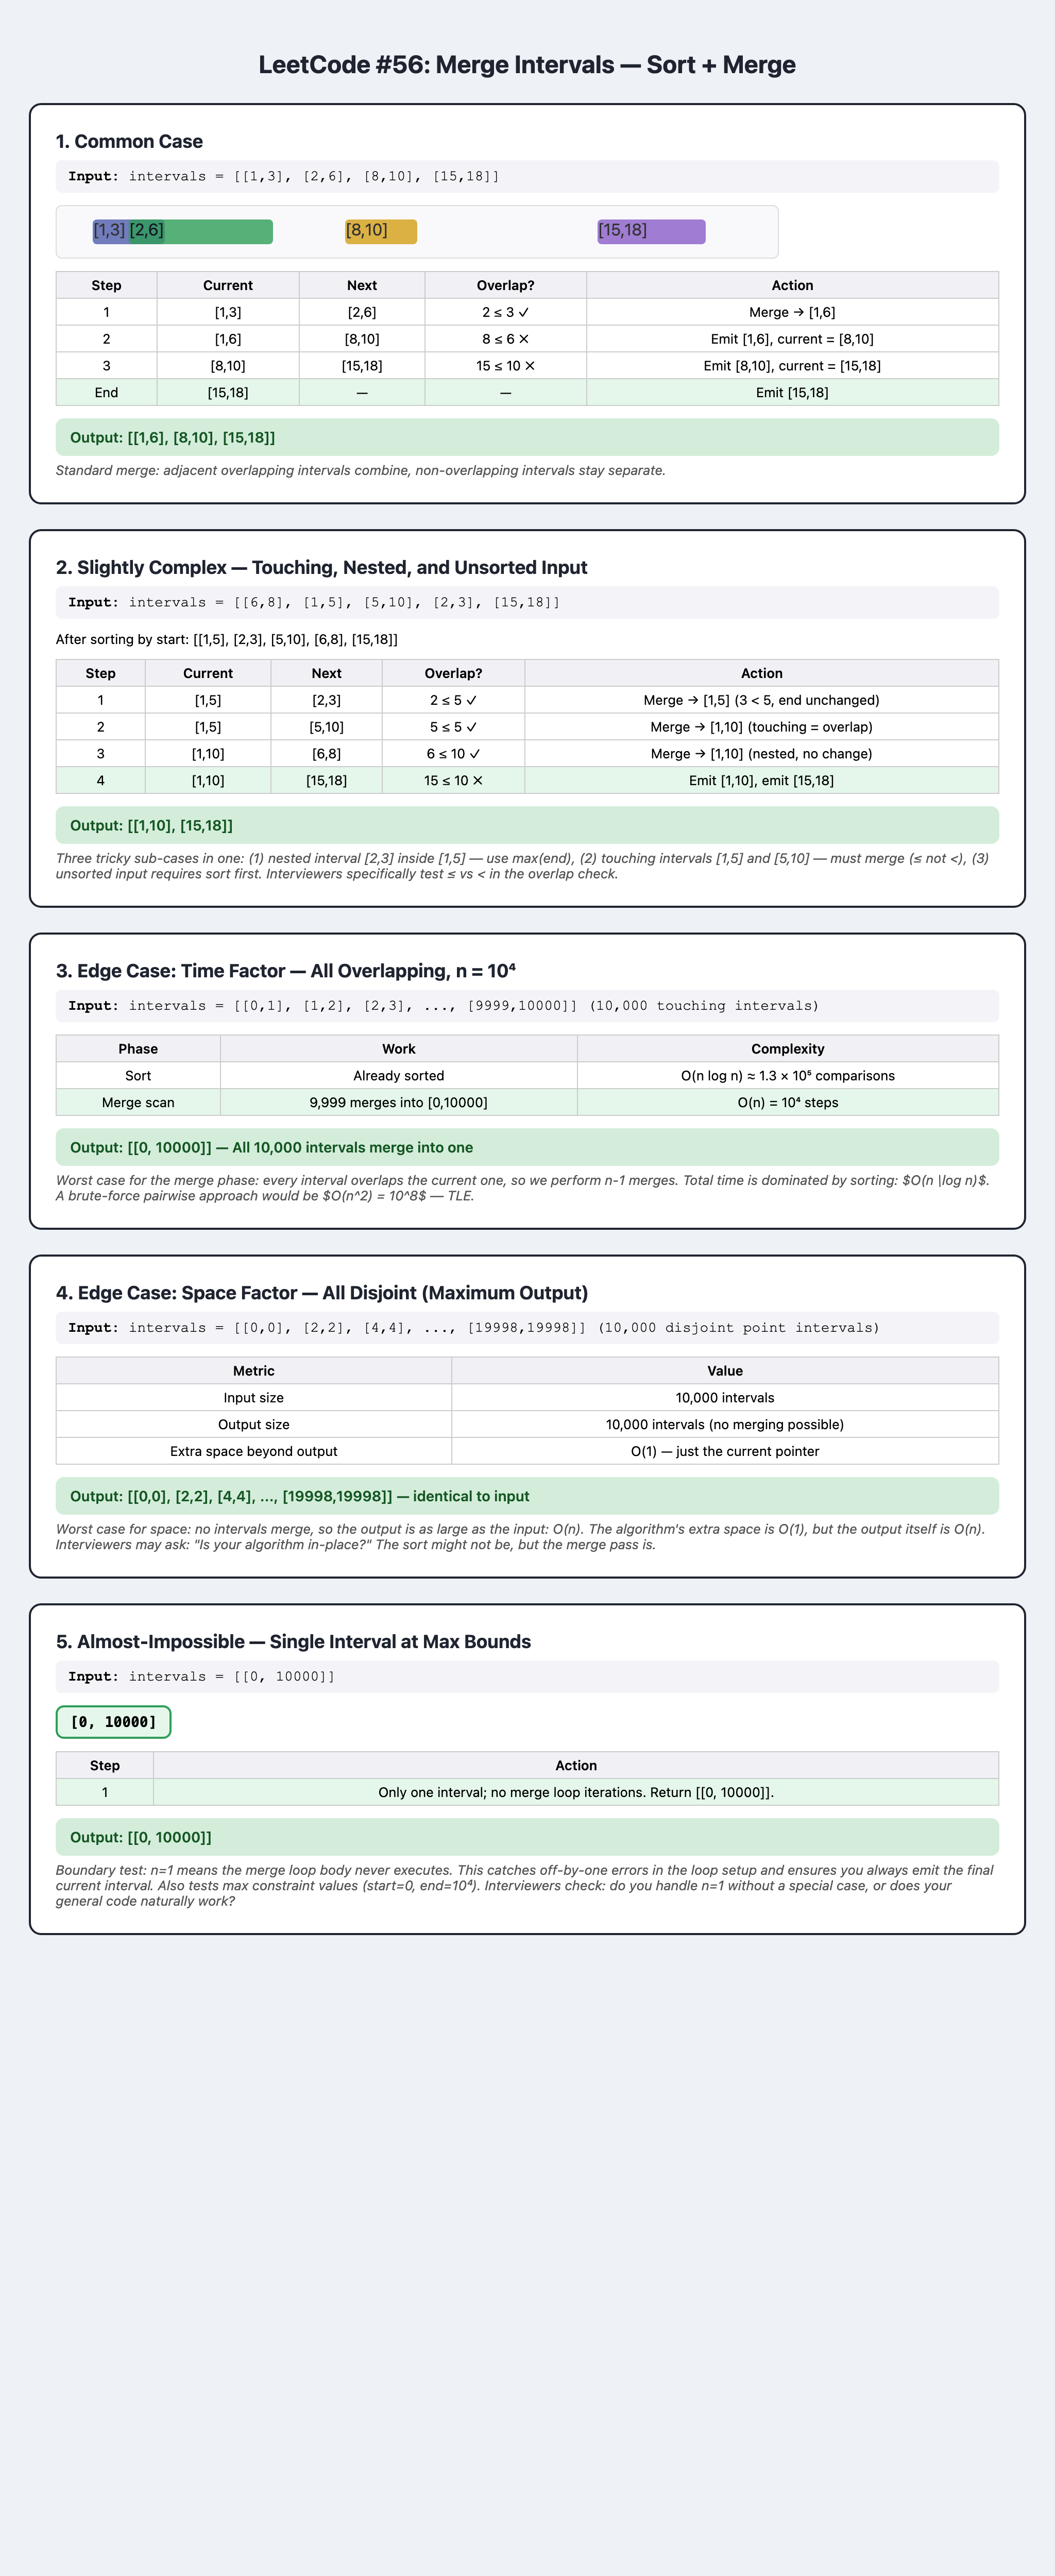